# FX Risk Exposure

**A Detailed, Python-based Introduction**

&copy; Dr. Yves J. Hilpisch

<a href="https://tpq.io" target="_blank">https://tpq.io</a> | <a href="https://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>

## What Is FX Risk?

**Foreign exchange (FX) risk** &mdash; also called **currency risk** &mdash; is the risk that the value of an asset, liability, cash flow or investment changes because of a **movement in the exchange rate** between two currencies.

Anyone who earns revenue, pays costs, holds assets or owes liabilities in a currency other than their **domestic (home/reporting) currency** is exposed to FX risk. The magnitude of the risk depends on

1. **how much** foreign currency is involved (the **size of the exposure**), and
2. **how volatile** the exchange rate is (the **uncertainty** of future FX movements).

In this notebook we walk through the **three classic types of FX exposure**, build a small **Monte Carlo simulation** of an exchange rate, quantify risk with **VaR / CVaR**, measure exposure with a **regression (market-style) model**, and finally illustrate the effect of a **simple hedge**.

## The Three Types of FX Exposure

| Exposure | Definition | Typical horizon | Kind of risk |
|---|---|---|---|
| **Transaction** | Individual, known cash flows in a foreign currency (bills, invoices, purchases). | Short term (days&ndash;months) | Realized P&L uncertainty on a specific deal |
| **Translation** | The impact of FX on the *reported value* of foreign assets/liabilities in financial statements. | Accounting / reporting periods | Book value (paper) fluctuation |
| **Economic** | The impact of FX on the *competitive position* and long-run cash flows of a firm. | Long term (years) | Future competitiveness & cash-flow value |

A European firm invoicing clients in USD faces **transaction** exposure on each invoice, **translation** exposure when its USD cash balances are converted back to EUR for reporting, and **economic** exposure because a persistently strong EUR makes its USD-priced products less competitive globally.

## A Word on Notation

We define the exchange rate $S_t$ as the **price of one unit of the foreign currency in domestic currency** (e.g. $S_t = 1.08$ means one USD costs 1.08 EUR).

- A **rise** in $S_t$ **(appreciation of the foreign currency / depreciation of the domestic currency)** increases the domestic value of a foreign-currency asset.
- A **fall** in $S_t$ **(depreciation of the foreign currency)** decreases that domestic value.

The **log return** is $r_t = \log(S_t / S_{t-1})$. Log returns are what we usually model and sum, because they are approximately additive over time.

In [1]:
import math
import numpy as np
import pandas as pd
from pylab import plt, mpl
np.set_printoptions(suppress=True)

In [2]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['figure.dpi'] = 130
mpl.rcParams['savefig.dpi'] = 130
mpl.rcParams['font.family'] = 'serif'
from numpy.random import default_rng
rng = default_rng(1000)  # reproducible

## Step 1 &mdash; Simulating an Exchange Rate (GBM)

We model the exchange rate $S_t$ with **Geometric Brownian Motion (GBM)**, the standard building block of log-normal price models:

$$dS_t = \mu S_t\, dt + \sigma S_t\, dW_t$$

over **daily** steps for one year (252 trading days). GBM keeps the exchange rate strictly positive, which matches reality. Parameters:

- initial rate $S_0 = 1.08$ (EUR price of 1 USD),
- annual drift $\mu = 0.0$ (flat medium-term expectation, we care about *risk*),
- annual volatility $\sigma = 0.12$ (12% annualized FX volatility).

We compute daily parameters $(\mu_{dt},\ \sigma_{dt})$ with the standard drift-correction: $\sigma_{dt} = \sigma/\sqrt{252}$ and generate the path.

In [3]:
S0 = 1.08          # initial EUR/USD-equivalent
mu = 0.0           # annual drift
sigma = 0.12       # annual volatility
M = 252            # daily steps (~one trading year)
dt = 1 / M

mu_dt = (mu - 0.5 * sigma ** 2) * dt
sigma_dt = sigma * math.sqrt(dt)

def gbm_path(S0, mu_dt, sigma_dt, M, rng):
    '''Simulate one GBM path of length M+1 (starts at S0).'''
    S = np.zeros(M + 1)
    S[0] = S0
    z = rng.standard_normal(M)
    S[1:] = S0 * np.exp(np.cumsum(mu_dt + sigma_dt * z))
    return S

dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=M + 1)
S = gbm_path(S0, mu_dt, sigma_dt, M, rng)

fx = pd.DataFrame(S, index=dates, columns=['S'])
fx.head()

,S
2025-09-24,1.080000
2025-09-25,1.077349
2025-09-26,1.073370
2025-09-29,1.087058
2025-09-30,1.103340


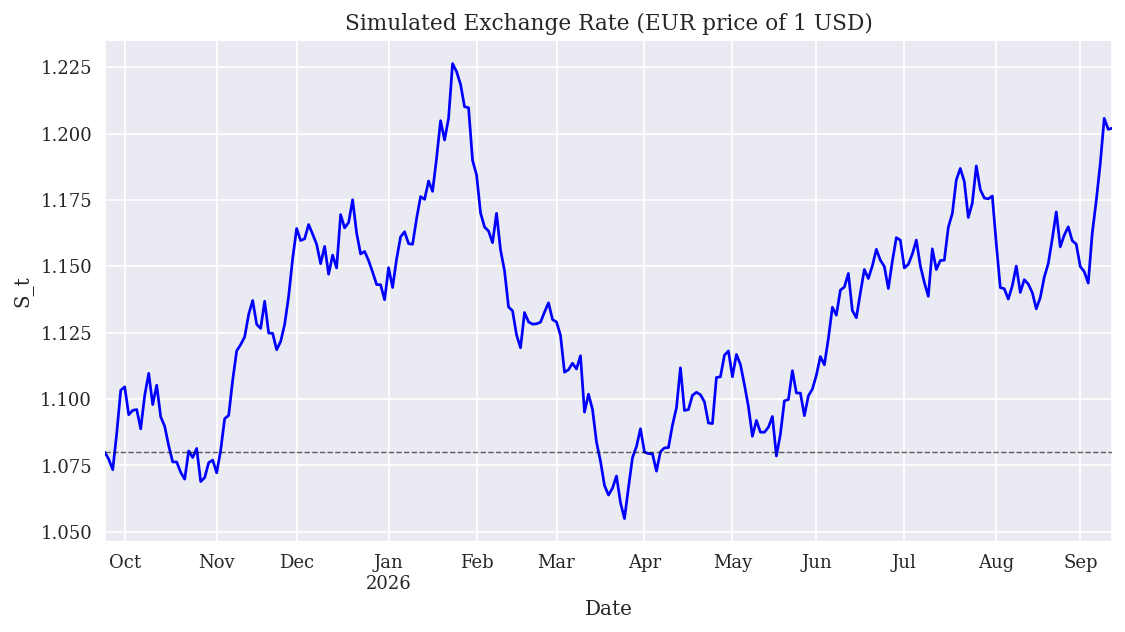

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
fx['S'].plot(ax=ax, lw=1.5, c='b')
ax.set(title='Simulated Exchange Rate (EUR price of 1 USD)',
       ylabel='S_t', xlabel='Date')
ax.axhline(S0, color='k', ls='--', lw=0.8, alpha=0.6)
plt.show()

## Step 2 &mdash; FX Returns and Their Distribution

The **risk** in an FX position is entirely driven by the *distribution* of the **log returns** $r_t$. From the single simulated path we compute

- the daily mean $\mu_d$ and daily volatility $\sigma_d$,
- the **annualized** volatility $\sigma_a = \sigma_d \sqrt{252}$,
- the **skewness** (asymmetry) and **excess kurtosis** (fat tails).

For a *true* log-normal model skewness should be near zero and excess kurtosis near zero; tail risk in real FX data is usually heavier than the normal model implies.

In [6]:
fx['r'] = np.log(fx['S'] / fx['S'].shift(1))
fx.dropna(inplace=True)

stats = pd.DataFrame({
    'daily mean': fx['r'].mean(),
    'daily vol': fx['r'].std(),
    'annualized vol': fx['r'].std() * np.sqrt(252),
    'skewness': fx['r'].skew(),
    'excess kurtosis': fx['r'].kurtosis(),
},
index=['value']).T
stats.round(4)

,value
daily mean,0.0004
daily vol,0.0072
annualized vol,0.1150
skewness,0.0048
excess kurtosis,-0.4937


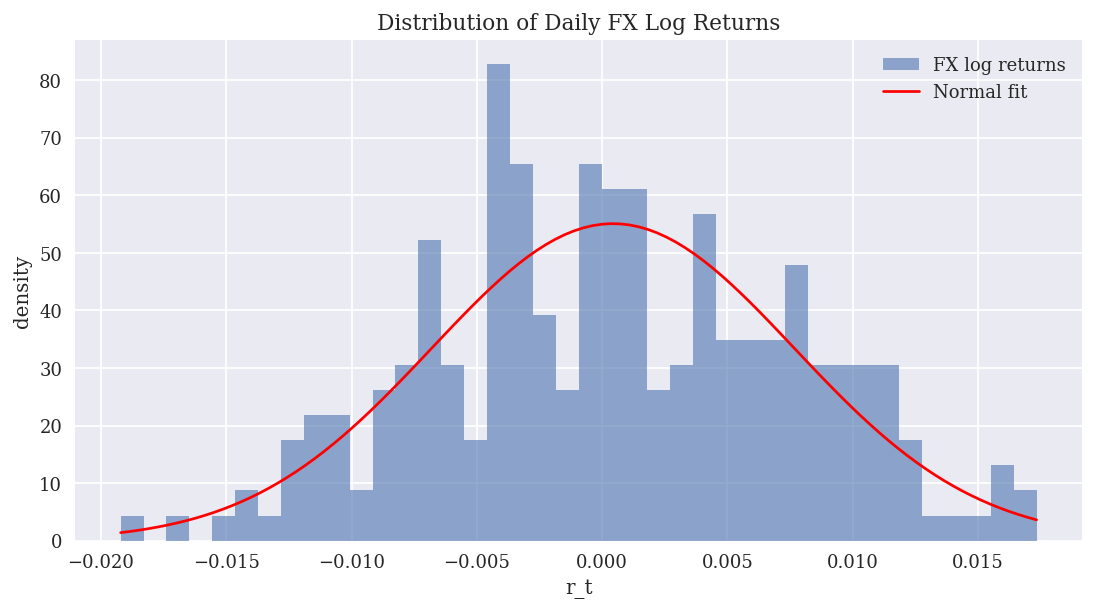

In [7]:
# --- histogram vs. normal density ---
x = np.linspace(fx['r'].min(), fx['r'].max(), 100)
mu_d, sd_d = fx['r'].mean(), fx['r'].std()
nrm = 1 / (sd_d * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu_d) / sd_d) ** 2)

fig, ax = plt.subplots(figsize=(10, 5))
fx['r'].hist(bins=40, density=True, ax=ax, alpha=0.6, label='FX log returns')
ax.plot(x, nrm, lw=1.5, color='r', label='Normal fit')
ax.set(title='Distribution of Daily FX Log Returns', xlabel='r_t', ylabel='density')
ax.legend()
plt.show()

## Step 3 &mdash; Measuring Risk: VaR and CVaR

Two of the most widely used risk measures for FX positions:

**Value at Risk (VaR)** at level $\alpha$ is the loss that will **not** be exceeded with probability $\alpha$ over a given horizon:

$$\text{VaR}_{\alpha} = -\,F^{-1}(\alpha)$$

where $F$ is the CDF of the (loss) distribution. For a long FX position a loss is a *negative* return, so we take the $\alpha$-quantile of the *returns* and negate it.

**Conditional Value at Risk (CVaR / Expected Shortfall)** is the *expected loss given that* a loss beyond VaR occurs:

$$\text{CVaR}_{\alpha} = -\mathbb{E}\,[\,r \mid r \le -\text{VaR}_{\alpha}\,]$$

CVaR is a **coherent** risk measure (it captures tail *beyond* VaR), so it is often preferred by regulators.

We illustrate **parametric** (normal) and **historical** (empirical) estimates from the simulated path.

alpha       = 0.95
VaR  (norm) = 0.0115  (1.15% per day)
CVaR (norm) = 0.0145  (1.45% per day)
VaR  (hist) = 0.0114  (1.14% per day)
CVaR (hist) = 0.0137  (1.37% per day)


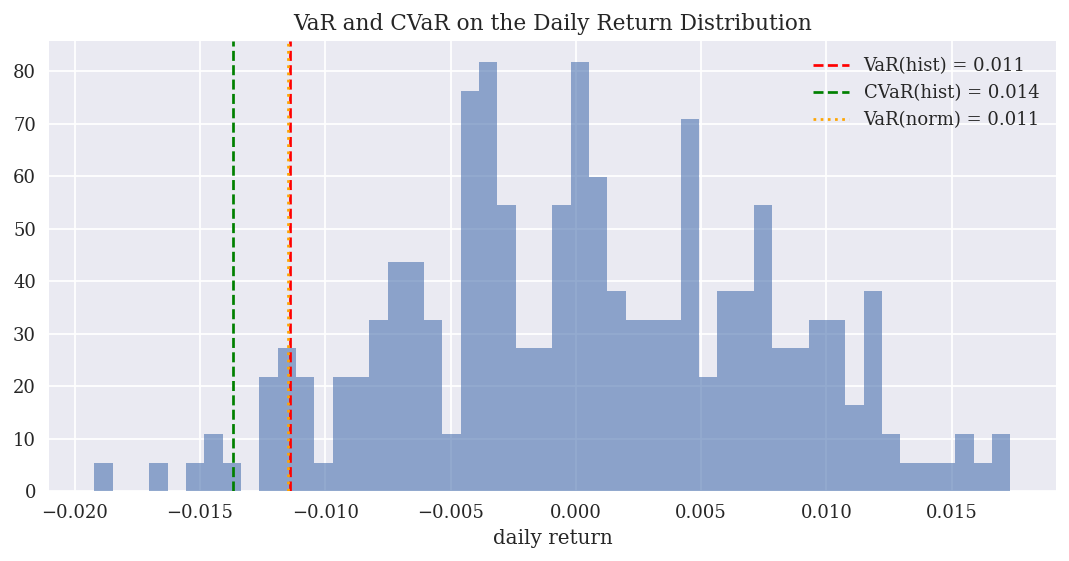

In [8]:
alpha = 0.95
r = fx['r'].values

from scipy.stats import norm
var_param = -norm.ppf(1 - alpha, mu_d, sd_d)
cvar_param = -(mu_d - sd_d * norm.pdf(norm.ppf(1 - alpha)) / (1 - alpha))

var_hist = -np.quantile(r, 1 - alpha)
tail = r[r <= -var_hist]
cvar_hist = -tail.mean() if len(tail) else np.nan

print(f'alpha       = {alpha}')
print(f'VaR  (norm) = {var_param:.4f}  ({var_param*100:.2f}% per day)')
print(f'CVaR (norm) = {cvar_param:.4f}  ({cvar_param*100:.2f}% per day)')
print(f'VaR  (hist) = {var_hist:.4f}  ({var_hist*100:.2f}% per day)')
print(f'CVaR (hist) = {cvar_hist:.4f}  ({cvar_hist*100:.2f}% per day)')

fig, ax = plt.subplots(figsize=(10, 4.5))
fx['r'].hist(bins=50, density=True, ax=ax, alpha=0.6)
ax.axvline(-var_hist, color='r', ls='--', lw=1.5, label=f'VaR(hist) = {var_hist:.3f}')
ax.axvline(-cvar_hist, color='g', ls='--', lw=1.5, label=f'CVaR(hist) = {cvar_hist:.3f}')
ax.axvline(-var_param, color='orange', ls=':', lw=1.5, label=f'VaR(norm) = {var_param:.3f}')
ax.legend()
ax.set(title='VaR and CVaR on the Daily Return Distribution', xlabel='daily return')
plt.show()

## Step 4 &mdash; Monte Carlo Simulation of FX Paths

A single path is just **one scenario**. To quantify *uncertainty* about the future exchange rate we simulate many independent paths and look at the **distribution of future values** $S_T$ after e.g. **21 trading days** (one calendar month).

From the ensemble of terminal values we derive **forecast bands** and can translate them straight into a **Value at Risk of the foreign-currency position**.

mean(S_T)      = 1.0797
std(S_T)       = 0.0375
2.5% quantile  = 1.0106
97.5% quantile = 1.1550


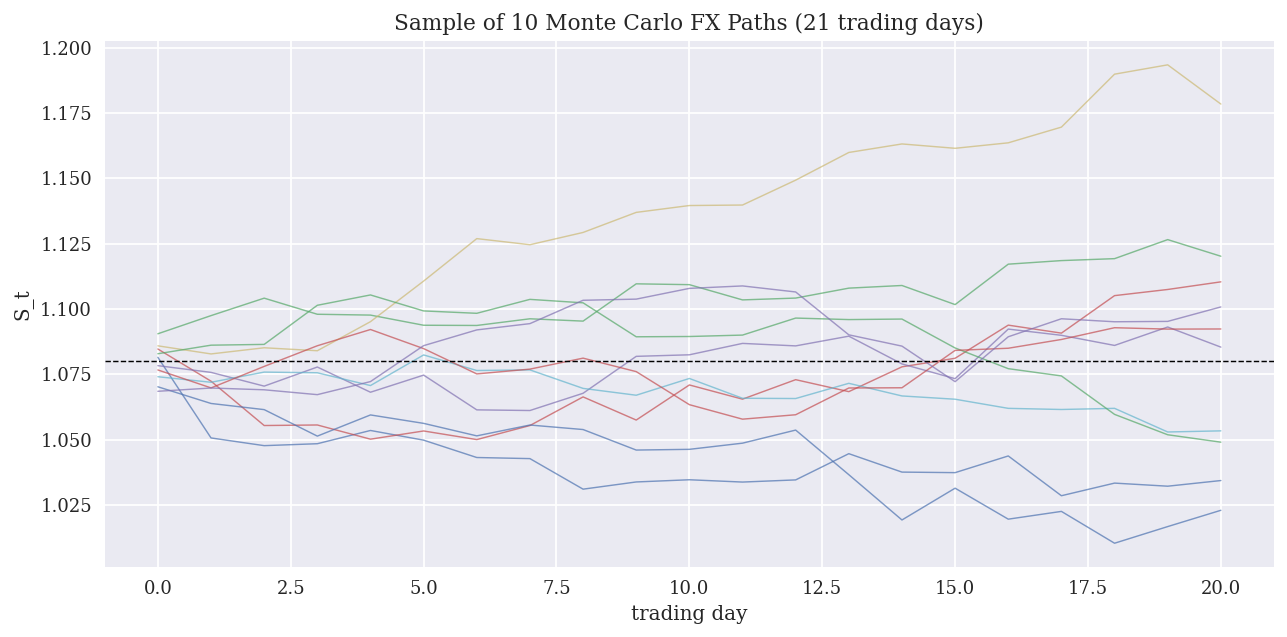

In [9]:
I = 5000          # number of simulated paths
H = 21            # forecasting horizon in trading days

z = rng.standard_normal((I, H))
cum = np.cumsum(mu_dt + sigma_dt * z, axis=1)
S_T = S0 * np.exp(cum)     # paths that start at S0

S_T_end = S_T[:, -1]
print(f'mean(S_T)      = {S_T_end.mean():.4f}')
print(f'std(S_T)       = {S_T_end.std():.4f}')
print(f'2.5% quantile  = {np.quantile(S_T_end, 0.025):.4f}')
print(f'97.5% quantile = {np.quantile(S_T_end, 0.975):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(10):
    ax.plot(S_T[i], lw=0.8, alpha=0.7)
ax.axhline(S0, color='k', ls='--', lw=0.8)
ax.set(title='Sample of 10 Monte Carlo FX Paths (21 trading days)',
       xlabel='trading day', ylabel='S_t')
plt.tight_layout()
plt.show()

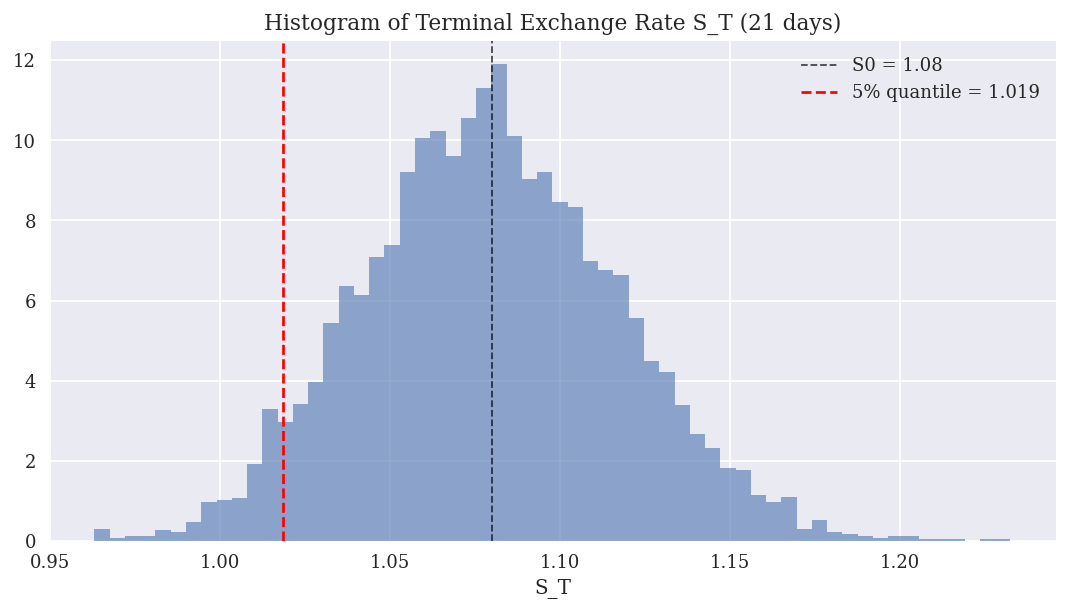

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(S_T_end, bins=60, density=True, alpha=0.6)
ax.axvline(S0, color='k', ls='--', lw=1, alpha=0.7, label=f'S0 = {S0}')
ax.axvline(np.quantile(S_T_end, 0.05), color='r', ls='--', lw=1.5,
            label=f'5% quantile = {np.quantile(S_T_end, 0.05):.3f}')
ax.set(title='Histogram of Terminal Exchange Rate S_T (21 days)', xlabel='S_T')
ax.legend()
plt.show()

## Step 5 &mdash; Translation Exposure: The Value of a Foreign Position

Consider a domestic company holding a **USD-denominated cash balance** (say \$2 million) that must be reported in **EUR** at month end. Its EUR value is

$$V_{EUR} = \text{USD balance} \times S_t$$

Because the USD balance is fixed, the *only* randomness comes from the exchange rate $S_t$. Using our Monte Carlo ensemble we simulate the distribution of the **EUR-translated value** at month end and quantify how much EUR value is at risk.

Today EUR value          = 2,160,000
MC expected EUR value    = 2,159,320
5% worst-case EUR value  = 2,037,296
95% VaR of EUR position  = 122,704  (5.68% of V0)
95% CVaR of EUR position = 148,397  (6.87% of V0)


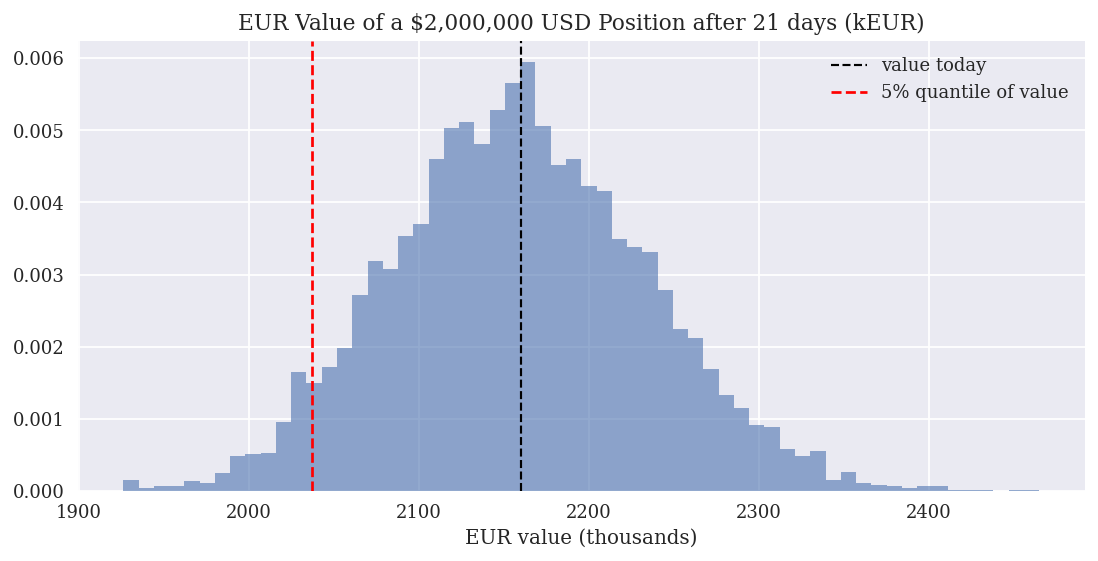

In [11]:
USD_QTY = 2_000_000.0          # foreign-currency exposure (USD)
V_T = USD_QTY * S_T_end        # EUR value of the position at month end
V0 = USD_QTY * S0

loss = V0 - V_T                # negative => a loss
var_95 = np.quantile(loss, 0.95)
cvar_95 = loss[loss >= var_95].mean() if (loss >= var_95).any() else np.nan

print(f'Today EUR value          = {V0:,.0f}')
print(f'MC expected EUR value    = {V_T.mean():,.0f}')
print(f'5% worst-case EUR value  = {np.quantile(V_T, 0.05):,.0f}')
print(f'95% VaR of EUR position  = {var_95:,.0f}  ({var_95/V0*100:.2f}% of V0)')
print(f'95% CVaR of EUR position = {cvar_95:,.0f}  ({cvar_95/V0*100:.2f}% of V0)')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(V_T / 1000, bins=60, density=True, alpha=0.6)
ax.axvline(V0 / 1000, color='k', ls='--', lw=1.2, label='value today')
ax.axvline(np.quantile(V_T, 0.05) / 1000, color='r', ls='--', lw=1.5,
            label='5% quantile of value')
ax.set(title=f'EUR Value of a ${USD_QTY:,.0f} USD Position after 21 days (kEUR)',
       xlabel='EUR value (thousands)')
ax.legend()
plt.show()

## Step 6 &mdash; Measuring Exposure with a Market-style Regression

A robust, data-driven way to measure the **linear sensitivity** of an asset's return to the FX rate is to regress asset returns $r_A$ on FX returns $r_{FX}$:

$$r_{A,t} = \alpha + \beta\, r_{FX,t} + \varepsilon_t$$

The estimated slope **$\hat\beta$** is the **exposure coefficient**: it says how strongly the asset co-moves with the currency. Values above 1 amplify FX moves, values between 0 and 1 dampen them, and negative betas mean the asset moves *against* the currency (a natural hedge).

To illustrate, we fabricate stylized firms sharing the same systematic FX driver but with different exposures $\beta \in \{0,\ 0.8,\ 1.6,\ -0.5\}$.

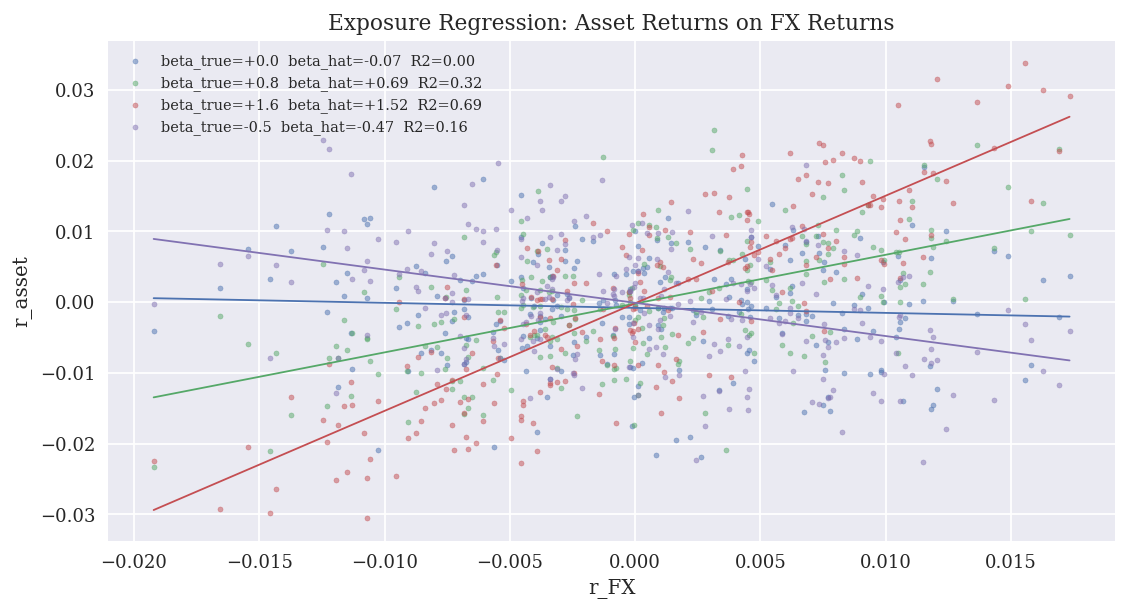

true beta +0.0  ->  estimated beta -0.07  (R2 = 0.00)
true beta +0.8  ->  estimated beta +0.69  (R2 = 0.32)
true beta +1.6  ->  estimated beta +1.52  (R2 = 0.69)
true beta -0.5  ->  estimated beta -0.47  (R2 = 0.16)


In [12]:
beta_true = [0.0, 0.8, 1.6, -0.5]
r_fx = fx['r'].values
n = len(r_fx)

results = {}
fig, ax = plt.subplots(figsize=(10, 5))
for b in beta_true:
    eps = rng.standard_normal(n) * r_fx.std()
    rA = b * r_fx + eps
    X = np.column_stack([np.ones(n), r_fx])
    coef, *_ = np.linalg.lstsq(X, rA, rcond=None)
    r2 = 1 - np.var(rA - X @ coef) / np.var(rA)
    results[b] = (coef[1], r2)
    ax.scatter(r_fx, rA, s=8, alpha=0.5,
               label=f'beta_true={b:+.1f}  beta_hat={coef[1]:+.2f}  R2={r2:.2f}')
    xx = np.linspace(r_fx.min(), r_fx.max(), 50)
    ax.plot(xx, coef[0] + coef[1] * xx, lw=1.0)

ax.set(title='Exposure Regression: Asset Returns on FX Returns',
       xlabel='r_FX', ylabel='r_asset')
ax.legend(fontsize=8)
plt.show()

for b, (bh, r2) in results.items():
    print(f'true beta {b:+.1f}  ->  estimated beta {bh:+.2f}  (R2 = {r2:.2f})')

## Step 7 &mdash; Hedging: Variance Reduction with a Forward

A common hedging strategy for transaction/translation exposure is a **forward or futures contract** that fixes the exchange rate for a future date. If we hedge a fraction $h \in [0, 1]$ of the local position, the hedged EUR value becomes

$$V^h_T = V_T + h\,(F - S_T)\, \times \, \text{USD quantity}$$

where $F$ is the contracted (fixed) rate. Here we take $F = S_0$ for simplicity: the unhedged value plus the (long) gain/loss on a **short forward** covering $h$ of the position. As $h$ grows, the variance of the domestic value shrinks &mdash; at $h = 1$ the position is fully locked at $S_0$ and FX volatility is eliminated (note that some *market* risk remains on whether $F=S_0$ was a good price).

Hedge fraction h  |  std (EUR)  |  mean (EUR)  |  std % of V0
      std (EUR)  mean (EUR)  std % of V0
0.00    74954.0   2159320.0          0.0
0.25    56215.0   2159490.0          0.0
0.50    37477.0   2159660.0          0.0
0.75    18738.0   2159830.0          0.0
1.00        0.0   2160000.0          0.0


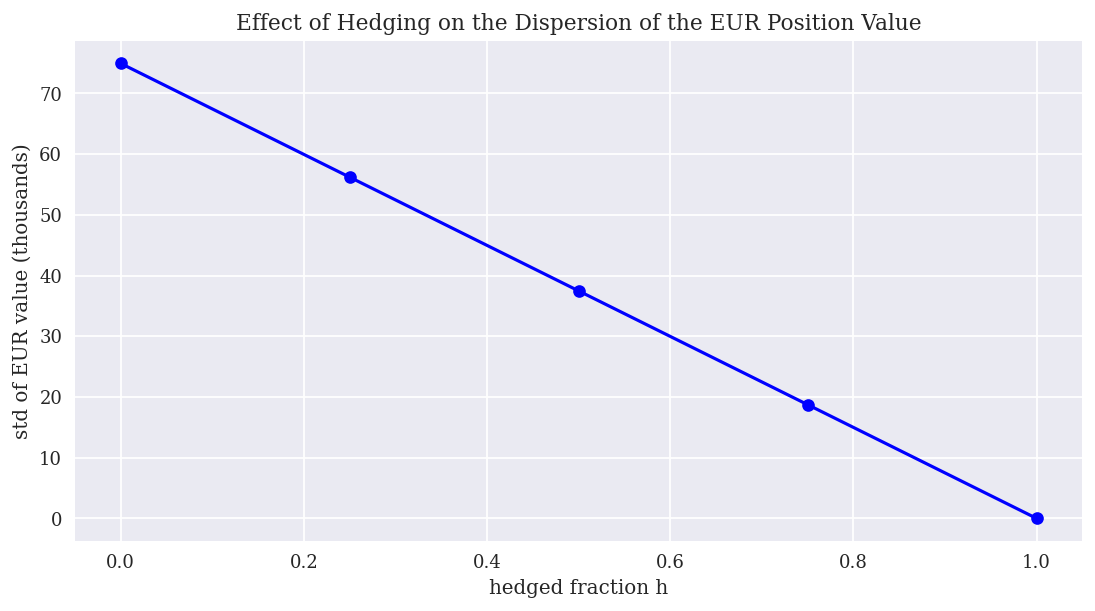

In [13]:
F = S0   # fixed forward rate used for the hedge
V_T = USD_QTY * S_T_end

hedge_levels = [0.0, 0.25, 0.5, 0.75, 1.0]
res = {}
for h in hedge_levels:
    V_h = V_T + h * (F - S_T_end) * USD_QTY
    res[h] = (V_h.std(), V_h.mean())

out = pd.DataFrame(res, index=['std (EUR)', 'mean (EUR)']).T
out['std % of V0'] = out['std (EUR)'] / V0
print('Hedge fraction h  |  std (EUR)  |  mean (EUR)  |  std % of V0')
print(out.round(0))

fig, ax = plt.subplots(figsize=(10, 5))
h_arr = np.array(hedge_levels)
ax.plot(h_arr, out['std (EUR)'] / 1000, 'o-', color='b')
ax.set(title='Effect of Hedging on the Dispersion of the EUR Position Value',
       xlabel='hedged fraction h', ylabel='std of EUR value (thousands)')
ax.grid(True)
plt.show()

## Summary

- **FX risk** is the risk that exchange-rate movements change the domestic-currency value of a foreign-currency position. Total risk = **size of exposure** &times; **FX volatility**.
- There are **three** exposure types: **transaction** (specific cash flows), **translation** (reported book values) and **economic** (long-run competitiveness).
- We model the exchange rate as **geometric Brownian motion** and use **Monte Carlo** to translate parameter risk into a *distribution* of future values.
- **VaR** gives a quantile-based loss number; **CVaR / Expected Shortfall** reports the expected loss in the tail and is a **coherent** measure.
- A **regression of asset returns on FX returns** yields an **exposure coefficient** $\beta$ that quantifies linear FX sensitivity.
- **Hedging** with forwards/futures reduces (and at $h=1$ eliminates) the *dispersion* of the domestic value, at the cost of giving up upside and leaving *market* risk on the fixing rate.

## Further Reading

- Y. Hilpisch, *Reinforcement Learning for Finance* (O'Reilly, 2024)
- Y. Hilpisch, *Python for Finance* (O'Reilly, 2nd ed., 2018)
- J. Hull, *Options, Futures, and Other Derivatives* (Pearson, 11th ed.)

---
&copy; Dr. Yves J. Hilpisch | The Python Quants GmbH | This notebook is for educational purposes and does **not** constitute investment advice.